## Неделя 3. Среда
### Временные ряды

В этом задании тебе предстоит проанализировать продажи разных категорий товаров. Сначала это стоит сделать для одной категории, потом можно попробовать для других. 

1. Загрузи [датасет](https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls) и распечатай первые 10 строк. 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly as ply
import seaborn as sns
import warnings
import datetime
import statsmodels as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [7]:
plt.style.use("seaborn-v0_8")

In [8]:
df = pd.read_excel("data/Sample - Superstore.xls")
df.shape

(9994, 21)

In [9]:
df.groupby("Category").count()["Row ID"]

Category
Furniture          2121
Office Supplies    6026
Technology         1847
Name: Row ID, dtype: int64

Сделай выбоорку по категории товара (используй популярную категорию: например, `Furniture`) и запиши в переменную `data`. Распечатай первые 10 строк. 

In [10]:
furn = df[df["Category"] == "Furniture"].copy()
furn.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,Pennsylvania,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,Utah,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
29,30,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
36,37,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


In [11]:
furn_sales_date = furn.loc[:, ["Order Date", "Sales"]].copy()
furn_sales_date["Order Date"] = pd.to_datetime(furn_sales_date["Order Date"])
furn_sales_date.set_index("Order Date", inplace=True)
furn_sales_date.index

DatetimeIndex(['2016-11-08', '2016-11-08', '2015-10-11', '2014-06-09',
               '2014-06-09', '2017-07-16', '2015-09-25', '2015-09-17',
               '2015-09-17', '2016-12-08',
               ...
               '2015-11-13', '2016-06-03', '2016-12-12', '2017-06-01',
               '2015-12-14', '2015-03-19', '2016-12-05', '2015-09-06',
               '2014-01-21', '2017-02-26'],
              dtype='datetime64[ns]', name='Order Date', length=2121, freq=None)

In [12]:
furn_sales_date.sort_index(inplace=True)
furn_sales_date.head()

,Sales
Order Date,
2014-01-06,2573.820
2014-01-07,76.728
2014-01-10,51.940
2014-01-11,9.940
2014-01-13,545.940


In [13]:
furn_sales_date.reset_index().to_csv("data/full_set.csv", index=None)

2. Визуализируй данные:
    * по исходному целевому столбцу (`Sales`)
    * усреднить просуммировать по разным периодам (неделя, месяц, квартал, полугодие)

##### График as is

''

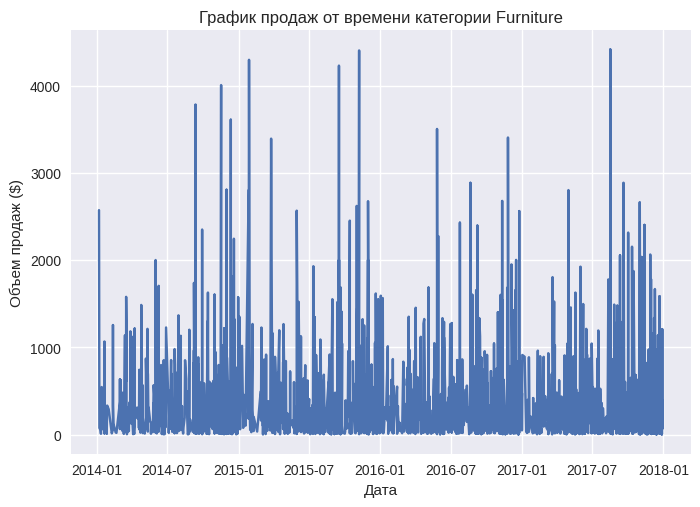

In [14]:
plt.plot(furn_sales_date.index, furn_sales_date.values)
plt.title("График продаж от времени категории Furniture")
plt.xlabel("Дата")
plt.ylabel("Объем продаж ($)")
;

##### Суммируем по неделям

''

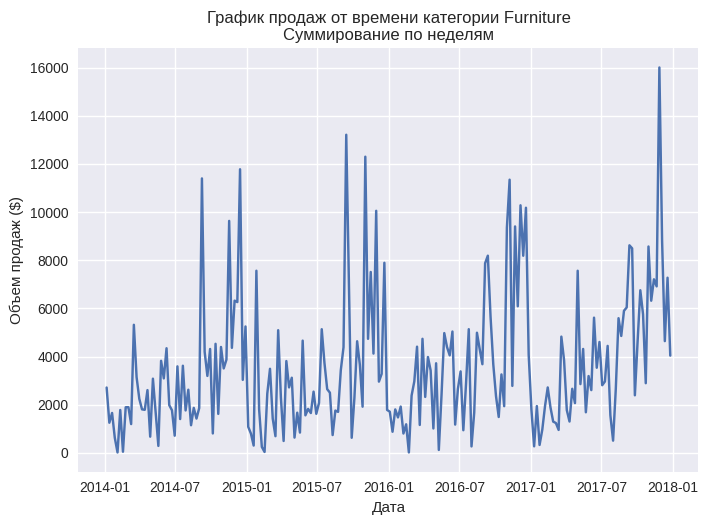

In [15]:
plt.plot(furn_sales_date.resample("7D").sum())
plt.title("График продаж от времени категории Furniture\nСуммирование по неделям")
plt.xlabel("Дата")
plt.ylabel("Объем продаж ($)")
;

##### Суммируем по месяцам

''

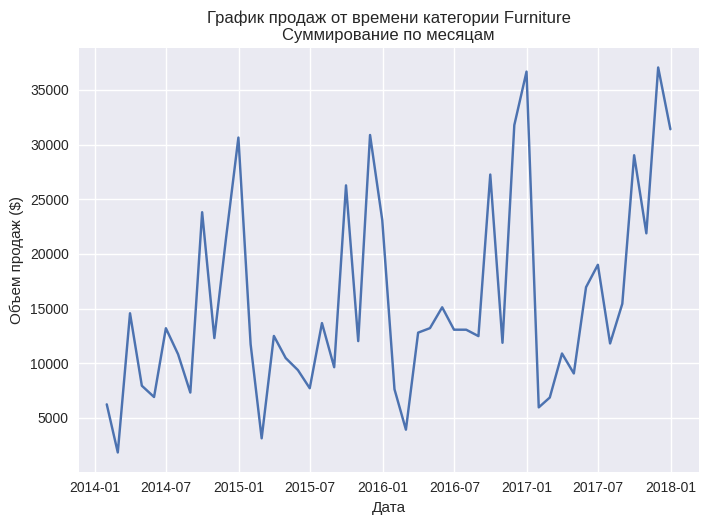

In [16]:
plt.plot(furn_sales_date.resample("M").sum())
plt.title("График продаж от времени категории Furniture\nСуммирование по месяцам")
plt.xlabel("Дата")
plt.ylabel("Объем продаж ($)")
;

##### Суммируем по кварталам

''

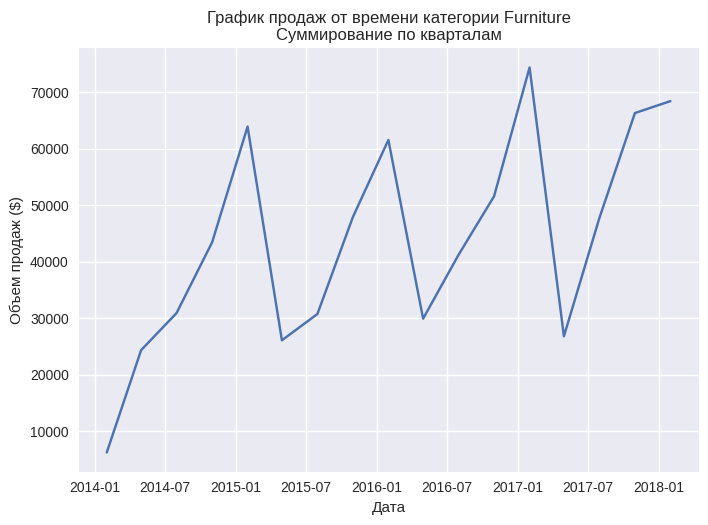

In [17]:
plt.plot(furn_sales_date.resample("3M").sum())
plt.title("График продаж от времени категории Furniture\nСуммирование по кварталам")
plt.xlabel("Дата")
plt.ylabel("Объем продаж ($)")
;

##### Суммируем по полугодиям

''

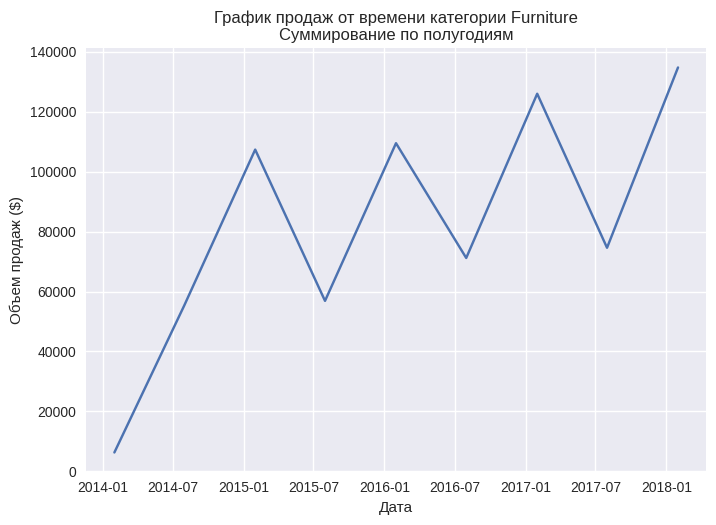

In [18]:
plt.plot(furn_sales_date.resample("6M").sum())
plt.title("График продаж от времени категории Furniture\nСуммирование по полугодиям")
plt.xlabel("Дата")
plt.ylabel("Объем продаж ($)")
;

2.1 В качестве анализа необходимо взять временной ряд по __неделям__, и анализировать __сумму__. 

In [19]:
data = furn_sales_date.resample("7D").sum().copy()
data.head()

,Sales
Order Date,
2014-01-06,2712.428
2014-01-13,1250.473
2014-01-20,1655.958
2014-01-27,623.666
2014-02-03,14.560


In [20]:
data.shape

(208, 1)

3. Построй визуализации:
* скользящего среднего


In [21]:
n_window = 4

moving_aver = data["Sales"].rolling(window=n_window, closed="left").mean()

moving_aver_mae = np.round(
    mean_absolute_error(data["Sales"][n_window:], moving_aver[n_window:]), 2
)
moving_aver_r2 = np.round(r2_score(data["Sales"][n_window:], moving_aver[n_window:]), 2)

''

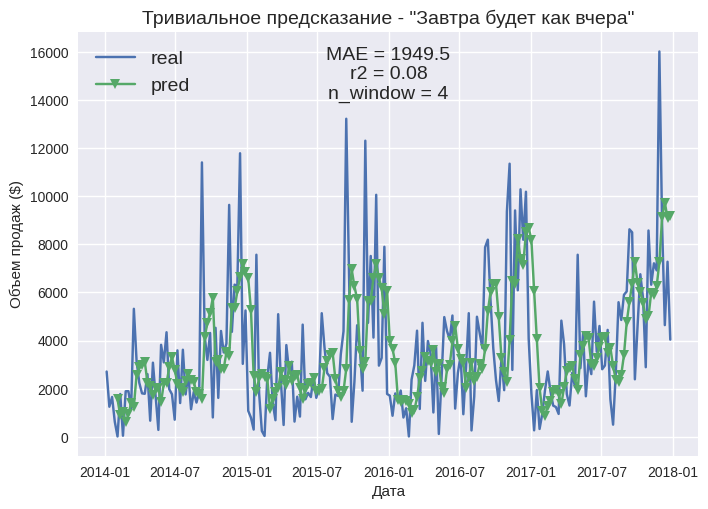

In [22]:
# display(f'MAE = {moving_average_mae}')
# display(f'r2 = {moving_average_r2}')
plt.plot(data["Sales"], label="real")
plt.plot(moving_aver, label="pred", marker="v")
plt.xlabel('Дата')
plt.ylabel('Объем продаж ($)')
plt.text(
    x=0.5, 
    y=0.9, 
    s=f'MAE = {moving_aver_mae}\nr2 = {moving_aver_r2}\nn_window = {n_window}', 
    transform=plt.gca().transAxes, 
    fontsize=14, 
    ha='center', 
    va='center',
    )
plt.legend(fontsize=14)
plt.title(f'Тривиальное предсказание - "Завтра будет как вчера"', fontsize=14)
;


* взвешенного скользящего среднего


In [23]:
def weighted_moving_average(x, n, weights):
    weights = np.array(weights)  # веса
    wmas = (
        x.rolling(n)
        .apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
        .to_list()
    )  #
    result = pd.Series(wmas, index=data.index).shift(1)
    return result

In [24]:
n_window2 = 12  # 3 месяца

weights = (
    [0.1] * 4 + [0.075] * 4 + [0.075] * 4
)  # самый ценный последний месяц, дальше вес падает
weighted_moving_average_pred = weighted_moving_average(
    data["Sales"], n=n_window2, weights=weights
)
weighted_moving_average_mae = np.round(
    mean_absolute_error(
        data["Sales"][n_window2:], weighted_moving_average_pred[n_window2:]
    ),
    2,
)
weighted_moving_average_r2 = np.round(
    r2_score(
        data["Sales"][n_window2:],
        weighted_moving_average_pred[n_window2:],
    ),
    2,
)

''

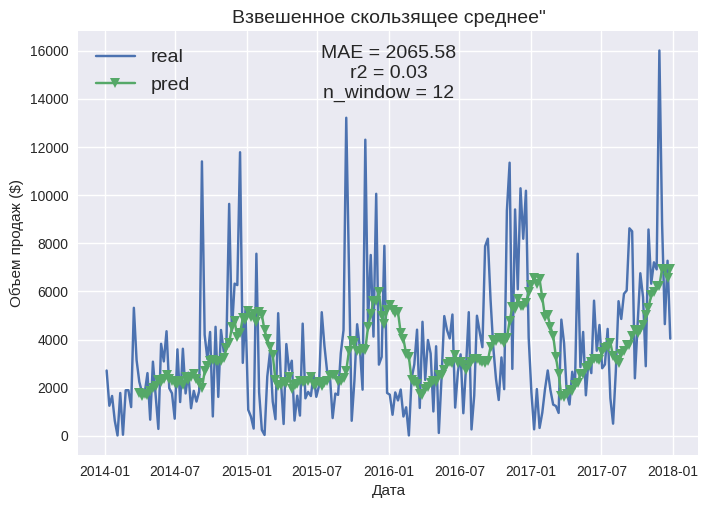

In [25]:
plt.plot(data["Sales"], label="real")
plt.plot(weighted_moving_average_pred, label="pred", marker="v")
plt.xlabel('Дата')
plt.ylabel('Объем продаж ($)')
plt.text(
    x=0.5, 
    y=0.9, 
    s=f'MAE = {weighted_moving_average_mae}\nr2 = {weighted_moving_average_r2}\nn_window = {n_window2}', 
    transform=plt.gca().transAxes, 
    fontsize=14, 
    ha='center', 
    va='center',
    )
plt.legend(fontsize=14)
plt.title(f'Взвешенное скользящее среднее"', fontsize=14)
;

Какие выводы можно сделать по скользящим линиям? Что они показывают?

4. Декомпозируй данные на тренд, сезонность и остатки. 

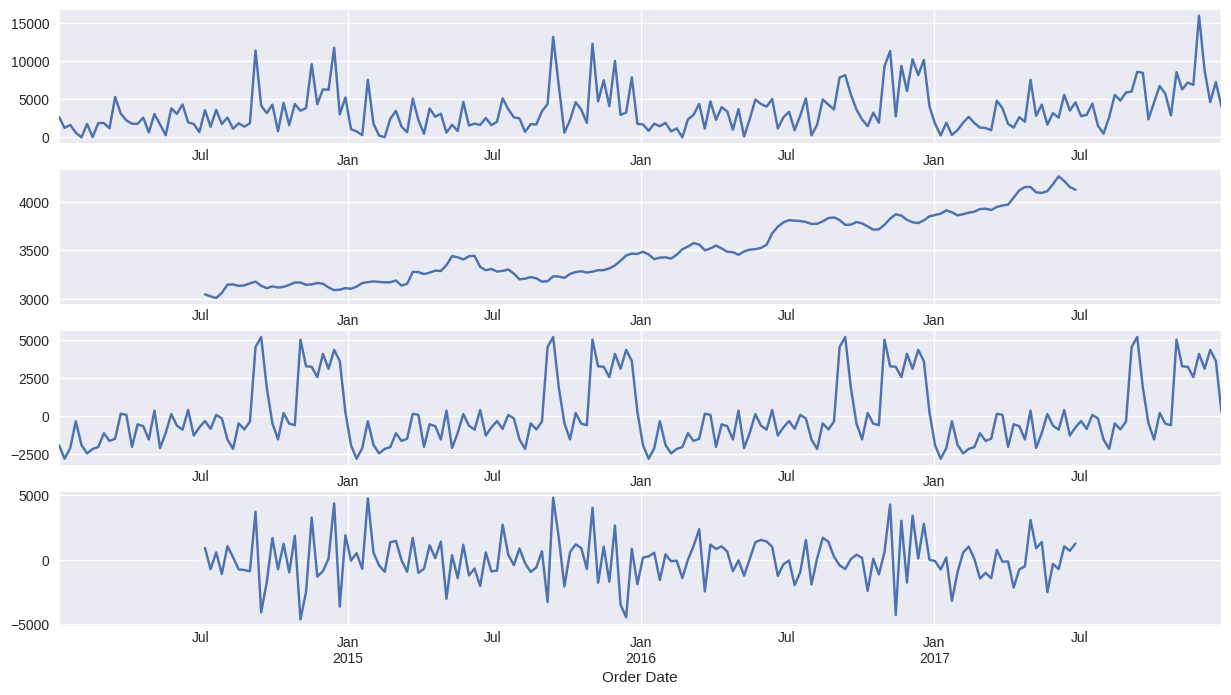

In [26]:
# Функция разложения временного ряда на тренд, компоненты сезонности и остатки (ошибки)
from statsmodels.tsa.seasonal import seasonal_decompose

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 8))
res = seasonal_decompose(data["Sales"])
res.observed.plot(ax=ax1)
res.trend.plot(ax=ax2)
res.seasonal.plot(ax=ax3)
res.resid.plot(ax=ax4)
plt.show()

# ❓
Прокомментируй графики: какой вывод можно сделать? Есть ли в данных сезонность? Какой тренд преобладает? Какого масштаба ошибки по сравнению со значениями основного временного ряда?

> Исходя из графиков можно сделать вывод, что преобладает тренд на рост продаж. Кроме того наблюдается достаточно выраженная сезонность с периодом 1 год - высокие продажи с сенятбря по январь. Однако на эти данные накладывается большая ошибка, достигающая ~100% от реального значения, что говорит о потенциально большой ошибке при посторении прогноза.

5. Построй графики автокорреляционной функции и частичной автокорреляционной функции. 

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

''

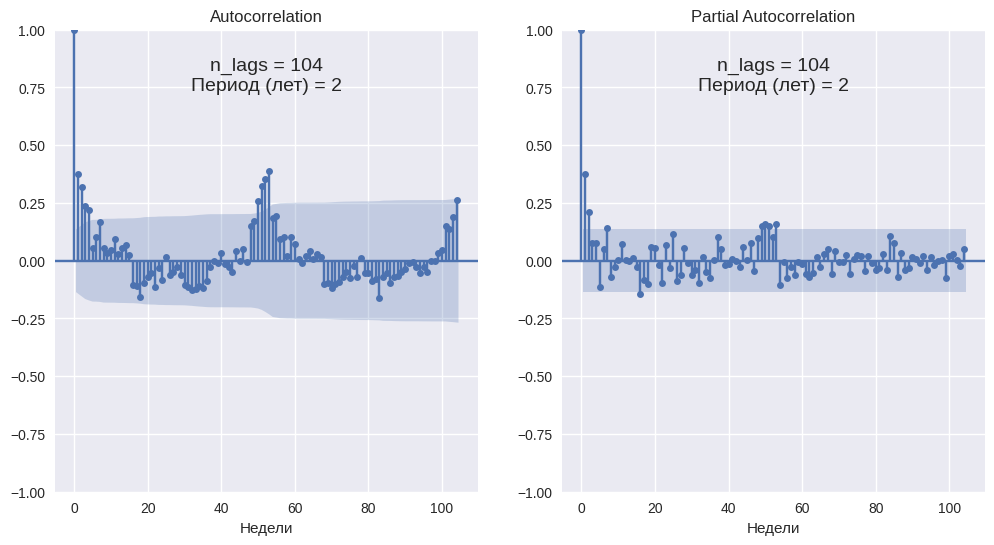

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
n_lags = 104
acf = plot_acf(data["Sales"], ax=ax1, lags=n_lags)
pacf = plot_pacf(data["Sales"], ax=ax2, lags=n_lags)
ax1.set_xlabel('Недели')
ax1.text(
    x=0.5,
    y=0.9,
    s=f"n_lags = {n_lags}\nПериод (лет) = {n_lags//48}",
    transform=ax1.transAxes,
    fontsize=14,
    ha="center",
    va="center",
)
ax2.set_xlabel('Недели')
ax2.text(
    x=0.5,
    y=0.9,
    s=f"n_lags = {n_lags}\nПериод (лет) = {n_lags//48}",
    transform=ax2.transAxes,
    fontsize=14,
    ha="center",
    va="center",
)
;

# ❓
Какие выводы можно сделать на основе этих графиков?

> Можно сделать вывод о годовой сезонности

6. Постройте и визуализируйте модель класса ARIMA

In [29]:
from statsmodels.tsa.ar_model import AutoReg

''

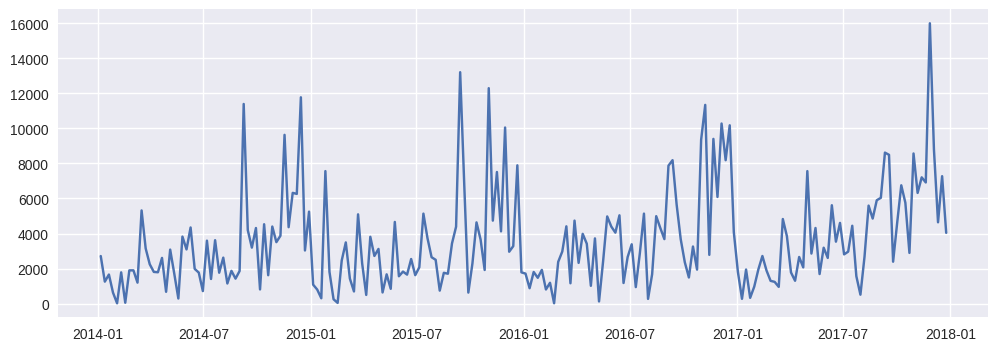

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(data["Sales"])
;

In [31]:
data_train = data[data["Sales"].index.year < 2017]
data_test = data[data["Sales"].index.year >= 2017]

In [32]:
lags = 52

ar = AutoReg(data_train, lags=lags).fit()


seasonality_period = 52
ar_pred_train = ar.fittedvalues  # предсказания для train


ar_pred = ar.forecast(
    len(data_test) + 2 * seasonality_period
)  # Предсказание для тестовых точек + еще на 3 сезона вперед
ar_pred_test, ar_pred_future = (
    ar_pred[: len(data_test)],
    ar_pred[len(data_test) :],
)  # Делим элементы из тестовой выборки и будущий периож


# plt.plot(
#     best_triple_exp.fittedvalues,
#     label=f'\u03B1 = {alpha}, \u03B2 = {betta}, \u03B3 = {gamma}; RMSE={rmse}', marker='v', color='k')

ar_mae = round(mean_absolute_error(data_test, ar_pred_test), 3)
ar_r2 = round(r2_score(data_test, ar_pred_test), 3)
print(f"mae = {ar_mae}")
print(f"r2 = {ar_r2}")

mae = 1854.98
r2 = 0.335


In [33]:
display("Веса авторегрессии")
ar.params

'Веса авторегрессии'

const        2789.264250
Sales.L1        0.126106
Sales.L2        0.097704
Sales.L3        0.112864
Sales.L4        0.036967
Sales.L5       -0.209690
Sales.L6        0.016330
Sales.L7        0.183077
Sales.L8       -0.081048
Sales.L9        0.000364
Sales.L10      -0.100562
Sales.L11       0.086339
Sales.L12      -0.035952
Sales.L13      -0.150152
Sales.L14       0.001061
Sales.L15       0.108187
Sales.L16       0.012297
Sales.L17      -0.003091
Sales.L18      -0.210556
Sales.L19      -0.031452
Sales.L20       0.096812
Sales.L21      -0.013253
Sales.L22      -0.089511
Sales.L23      -0.013967
Sales.L24      -0.029256
Sales.L25       0.066497
Sales.L26      -0.093008
Sales.L27      -0.082297
Sales.L28       0.131427
Sales.L29       0.090896
Sales.L30      -0.138801
Sales.L31      -0.082796
Sales.L32      -0.031944
Sales.L33       0.137471
Sales.L34       0.022010
Sales.L35      -0.163600
Sales.L36      -0.121794
Sales.L37       0.057948
Sales.L38       0.128834
Sales.L39       0.006257


''

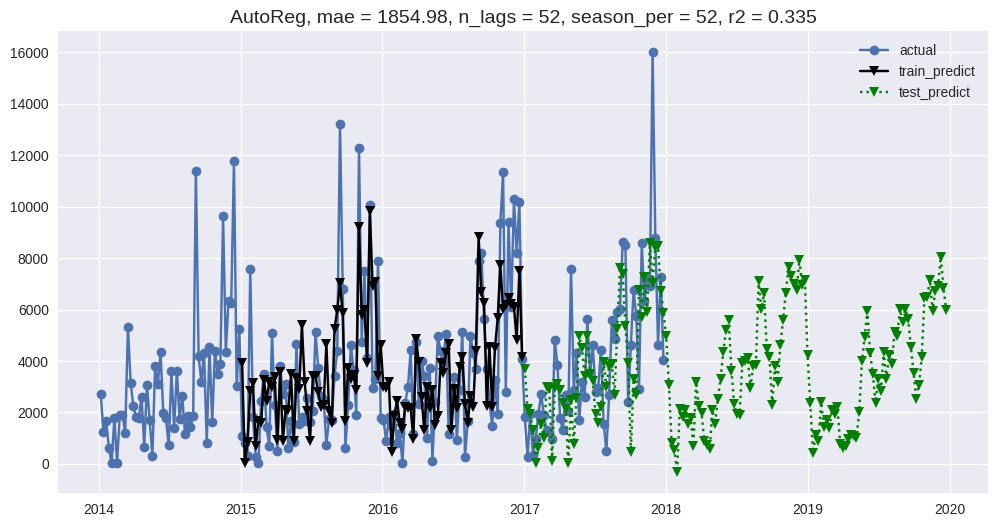

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(data["Sales"], label="actual", marker="o")
plt.plot(ar_pred_train, marker="v", color="k", label="train_predict")
plt.plot(
    pd.concat((ar_pred_test, ar_pred_future)),
    marker="v",
    color="g",
    label="test_predict",
    linestyle=":",
)
plt.legend()
plt.title(f"AutoReg, mae = {ar_mae}, n_lags = {lags}, season_per = {seasonality_period}, r2 = {ar_r2}", fontsize=14)
plt.savefig('figures/Autoreg.png', dpi=300, bbox_inches='tight')
;

7. Постройте и визуализируйте модель prophet. Попробуйте подобрать оптимальные параметры

In [35]:
from prophet import Prophet

In [36]:
data.head()

,Sales
Order Date,
2014-01-06,2712.428
2014-01-13,1250.473
2014-01-20,1655.958
2014-01-27,623.666
2014-02-03,14.560


In [37]:
data_prophet = (
    data["Sales"].reset_index().rename(columns={"Order Date": "ds", "Sales": "y"})
)
data_prophet.to_csv("data/data_prophet.csv", index=False)
data_prophet.head()

,ds,y
0,2014-01-06,2712.428
1,2014-01-13,1250.473
2,2014-01-20,1655.958
3,2014-01-27,623.666
4,2014-02-03,14.560


In [38]:
data_prophet_train = data_prophet[data_prophet["ds"].dt.year < 2017]
data_prophet_test = data_prophet[data_prophet["ds"].dt.year >= 2017]

##### Подбор параметров модели

In [142]:
import itertools
import logging

logging.getLogger("cmdstanpy").setLevel(logging.ERROR)  # Выключение логов

number_of_future_predicted_points = 3 * seasonality_period
param_grid = {
    "changepoint_prior_scale": list(np.arange(0.01, 0.5, 0.04)),
    "seasonality_prior_scale": list(np.arange(1, 10, 0.5)),
}

# Generate all combinations of parameters
all_params = [
    dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())
]
maes = []  # Store the MAEs for each params here

# Use validation to evaluate all parameters
for params in all_params:
    model = Prophet(**params).fit(
        data_prophet_train
    )  # Обучаем модель с заданными параметрами
    future = model.make_future_dataframe(
        periods=number_of_future_predicted_points, freq="M"
    )  # Создаем фрейм данных для будущего (для тестовой выборки)
    forecast = model.predict(future)  # Делаем предсказание на будущее
    forecast_test = forecast[
        -number_of_future_predicted_points : -number_of_future_predicted_points
        + len(data_test)
    ]
    prophet_mae_test = np.round(
        mean_absolute_error(data_prophet_test["y"], forecast_test["yhat"]), 1
    )
    maes.append(prophet_mae_test)  # Добавляем RMSE для данного набора параметров

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results["maes"] = maes

In [143]:
tuning_results.sort_values(by="maes")

,changepoint_prior_scale,seasonality_prior_scale,maes
41,0.09,3.5,2028.6
48,0.09,7.0,2032.7
37,0.09,1.5,2034.2
44,0.09,5.0,2034.7
69,0.13,8.5,2035.7
...,...,...,...
226,0.49,6.0,2768.7
224,0.49,5.0,2770.8
218,0.49,2.0,2777.0
216,0.49,1.0,2786.0


In [144]:
prophet_model = Prophet(changepoint_prior_scale=0.09, seasonality_prior_scale=3.5)
prophet_model.fit(data_prophet_train)

In [145]:
# seasonality_period = 52 (объявлен ранее для Autoreg)
prediction_points = 3 * seasonality_period

future = prophet_model.make_future_dataframe(periods=prediction_points, freq="7D")
forecast = prophet_model.predict(future)

In [146]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-06,2825.353368,-1306.485263,3694.345356,2825.353368,2825.353368,-1704.854009,-1704.854009,-1704.854009,-1704.854009,-1704.854009,-1704.854009,0.0,0.0,0.0,1120.499359
1,2014-01-13,2832.442220,-1467.427296,3222.290750,2832.442220,2832.442220,-2032.011210,-2032.011210,-2032.011210,-2032.011210,-2032.011210,-2032.011210,0.0,0.0,0.0,800.431010
2,2014-01-20,2839.531072,-1159.848561,3810.408394,2839.531072,2839.531072,-1489.518004,-1489.518004,-1489.518004,-1489.518004,-1489.518004,-1489.518004,0.0,0.0,0.0,1350.013068
3,2014-01-27,2846.619924,-610.171586,4146.341334,2846.619924,2846.619924,-1078.996863,-1078.996863,-1078.996863,-1078.996863,-1078.996863,-1078.996863,0.0,0.0,0.0,1767.623060
4,2014-02-03,2853.708775,-1115.234459,3867.981456,2853.708775,2853.708775,-1444.186520,-1444.186520,-1444.186520,-1444.186520,-1444.186520,-1444.186520,0.0,0.0,0.0,1409.522255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,2019-11-25,5001.643488,5534.555784,10232.158468,5001.640829,5001.646395,2875.693114,2875.693114,2875.693114,2875.693114,2875.693114,2875.693114,0.0,0.0,0.0,7877.336602
308,2019-12-02,5008.732399,6104.460955,10896.844238,5008.729715,5008.735338,3460.897870,3460.897870,3460.897870,3460.897870,3460.897870,3460.897870,0.0,0.0,0.0,8469.630269
309,2019-12-09,5015.821310,6847.977235,11397.135814,5015.818592,5015.824283,4052.449824,4052.449824,4052.449824,4052.449824,4052.449824,4052.449824,0.0,0.0,0.0,9068.271135
310,2019-12-16,5022.910222,6433.311977,11245.108324,5022.907473,5022.913233,3747.363562,3747.363562,3747.363562,3747.363562,3747.363562,3747.363562,0.0,0.0,0.0,8770.273784


(-2500.0, 15000.0)

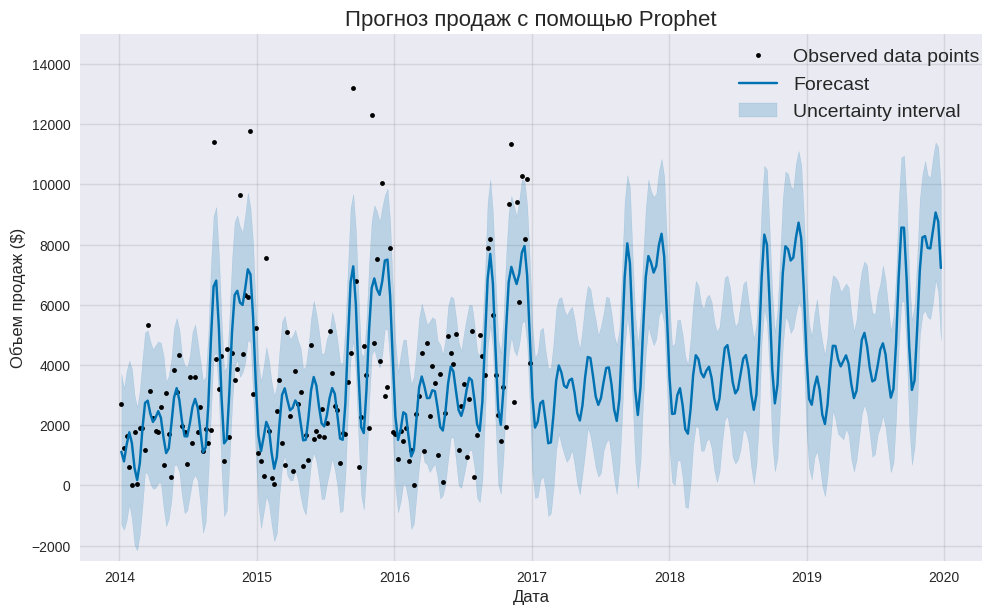

In [147]:
fig_prophet = prophet_model.plot(forecast)
fig_prophet.legend(fontsize=14, loc="upper right", bbox_to_anchor=(1, 0.98))
plt.title("Прогноз продаж с помощью Prophet", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Объем продаж ($)", fontsize=12)
plt.ylim((-2500, 15000))

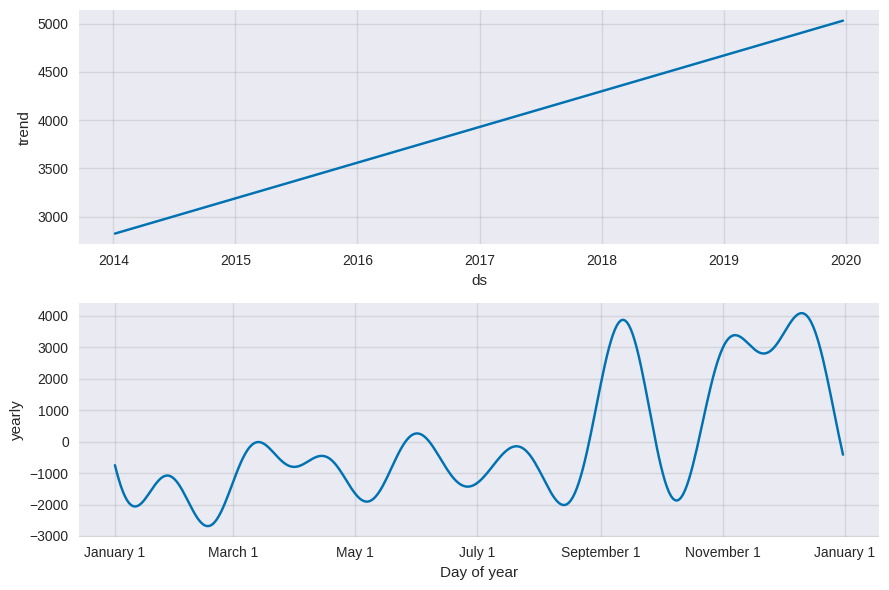

In [148]:
figure_comp = prophet_model.plot_components(forecast)

8. Примени регрессионные модели (случайный лес или градиентный бустинг) для прогнозирования целевой величины.
   * Пример есть в демо

##### Функция подготовки данных

In [72]:
def code_mean(data, cat_feature, real_feature):
    """
    Возвращает словарь, где ключами являются уникальные категории признака cat_feature,
    а значениями - средние по real_feature
    """
    return dict(data.groupby(cat_feature)[real_feature].mean())


def prepareData(data, lag_start=1, lag_end=52, test_size=0.2):

    data = pd.DataFrame(data.copy())
    data.columns = ["y"]

    # считаем индекс в датафрейме, после которого начинается тестовый отрезок
    test_index = int(len(data) * (1 - test_size))

    # добавляем лаги исходного ряда в качестве признаков
    for i in range(lag_start, lag_end):
        data["lag_{}".format(i)] = data.y.shift(i)

    # data.index = data.index.to_datetime()
    data["month"] = data.index.month
    # data["weekday"] = data.index.weekday
    # data["is_weekend"] = data.weekday.isin([5, 6]) * 1

    # считаем средние только по тренировочной части, чтобы избежать лика
    # data["weekday_average"] = list(
    #     map(code_mean(data[:test_index], "weekday", "y").get, data.weekday)
    # )
    data["month_average"] = list(
        map(code_mean(data[:test_index], "month", "y").get, data.month)
    )

    # выкидываем закодированные средними признаки
    data.drop(["month"], axis=1, inplace=True)
    # data.drop(["month", "weekday"], axis=1, inplace=True)

    data = data.dropna()
    data = data.reset_index(drop=True)

    # разбиваем весь датасет на тренировочную и тестовую выборку
    X_train = data.loc[:test_index].drop(["y"], axis=1)
    y_train = data.loc[:test_index]["y"]
    X_test = data.loc[test_index:].drop(["y"], axis=1)
    y_test = data.loc[test_index:]["y"]

    return X_train, X_test, y_train, y_test

##### Строим модель

In [69]:
data

,Sales
Order Date,
2014-01-06,2712.4280
2014-01-13,1250.4730
2014-01-20,1655.9580
2014-01-27,623.6660
2014-02-03,14.5600
...,...
2017-11-27,16008.1720
2017-12-04,8794.4040
2017-12-11,4639.8190


In [82]:
from sklearn.ensemble import RandomForestRegressor

In [106]:
X_train, X_test, y_train, y_test = prepareData(
    data, test_size=0.3, lag_start=1, lag_end=52
)

In [107]:
X_train

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,lag_32,lag_33,lag_34,lag_35,lag_36,lag_37,lag_38,lag_39,lag_40,lag_41,lag_42,lag_43,lag_44,lag_45,lag_46,lag_47,lag_48,lag_49,lag_50,lag_51,month_average
0,3030.6780,11779.8120,6262.4145,6321.5980,4360.9070,9634.7920,3873.2737,3506.1760,4397.7540,1617.2280,4528.6380,805.1020,4313.8770,3194.3518,4195.0380,11399.2960,1859.1670,1423.0785,1867.1760,1146.0180,2621.1960,1760.6060,3617.7860,1402.8120,3591.5090,711.2160,1766.5570,1979.1276,4344.5460,3091.8350,3822.3690,287.2840,1707.2940,3080.2600,670.644,2605.650,1786.568,1805.081,2242.022,3146.383,5318.368,1193.936,1895.786,1893.995,45.4800,1779.6180,14.5600,623.6660,1655.9580,1250.4730,2712.4280,5395.226256
1,5248.5316,3030.6780,11779.8120,6262.4145,6321.5980,4360.9070,9634.7920,3873.2737,3506.1760,4397.7540,1617.2280,4528.6380,805.1020,4313.8770,3194.3518,4195.0380,11399.2960,1859.1670,1423.0785,1867.1760,1146.0180,2621.1960,1760.6060,3617.7860,1402.8120,3591.5090,711.2160,1766.5570,1979.1276,4344.5460,3091.8350,3822.3690,287.2840,1707.2940,3080.260,670.644,2605.650,1786.568,1805.081,2242.022,3146.383,5318.368,1193.936,1895.786,1893.9950,45.4800,1779.6180,14.5600,623.6660,1655.9580,1250.4730,1820.112667
2,1079.6880,5248.5316,3030.6780,11779.8120,6262.4145,6321.5980,4360.9070,9634.7920,3873.2737,3506.1760,4397.7540,1617.2280,4528.6380,805.1020,4313.8770,3194.3518,4195.0380,11399.2960,1859.1670,1423.0785,1867.1760,1146.0180,2621.1960,1760.6060,3617.7860,1402.8120,3591.5090,711.2160,1766.5570,1979.1276,4344.5460,3091.8350,3822.3690,287.2840,1707.294,3080.260,670.644,2605.650,1786.568,1805.081,2242.022,3146.383,5318.368,1193.936,1895.7860,1893.9950,45.4800,1779.6180,14.5600,623.6660,1655.9580,1820.112667
3,797.1940,1079.6880,5248.5316,3030.6780,11779.8120,6262.4145,6321.5980,4360.9070,9634.7920,3873.2737,3506.1760,4397.7540,1617.2280,4528.6380,805.1020,4313.8770,3194.3518,4195.0380,11399.2960,1859.1670,1423.0785,1867.1760,1146.0180,2621.1960,1760.6060,3617.7860,1402.8120,3591.5090,711.2160,1766.5570,1979.1276,4344.5460,3091.8350,3822.3690,287.284,1707.294,3080.260,670.644,2605.650,1786.568,1805.081,2242.022,3146.383,5318.368,1193.9360,1895.7860,1893.9950,45.4800,1779.6180,14.5600,623.6660,1820.112667
4,301.7420,797.1940,1079.6880,5248.5316,3030.6780,11779.8120,6262.4145,6321.5980,4360.9070,9634.7920,3873.2737,3506.1760,4397.7540,1617.2280,4528.6380,805.1020,4313.8770,3194.3518,4195.0380,11399.2960,1859.1670,1423.0785,1867.1760,1146.0180,2621.1960,1760.6060,3617.7860,1402.8120,3591.5090,711.2160,1766.5570,1979.1276,4344.5460,3091.8350,3822.369,287.284,1707.294,3080.260,670.644,2605.650,1786.568,1805.081,2242.022,3146.383,5318.3680,1193.9360,1895.7860,1893.9950,45.4800,1779.6180,14.5600,1820.112667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,6038.8250,5900.2410,4854.5880,5592.7900,2670.6860,505.4320,1562.4320,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.580,1806.410,4078.778,10181.337,8186.791,10282.552,6087.365,9404.303,2779.976,11346.386,9356.0708,1937.1920,3256.6640,1488.1500,2357.5600,3675.3513,5649.5510,5797.521285
142,8620.5420,6038.8250,5900.2410,4854.5880,5592.7900,2670.6860,505.4320,1562.4320,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.327,269.580,1806.410,4078.778,101

In [108]:
y_train

0      5248.5316
1      1079.6880
2       797.1940
3       301.7420
4      7564.2500
         ...    
141    8620.5420
142    8494.1200
143    2389.5760
144    4619.6080
145    6753.4950
Name: y, Length: 146, dtype: float64

In [109]:
X_test

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,lag_32,lag_33,lag_34,lag_35,lag_36,lag_37,lag_38,lag_39,lag_40,lag_41,lag_42,lag_43,lag_44,lag_45,lag_46,lag_47,lag_48,lag_49,lag_50,lag_51,month_average
145,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.2410,4854.5880,5592.7900,2670.6860,505.4320,1562.432,4442.237,2963.551,2807.842,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.7780,10181.3370,8186.7910,10282.5520,6087.3650,9404.303,2779.976,11346.386,9356.0708,1937.1920,3256.6640,2769.037150
146,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.2410,4854.5880,5592.7900,2670.6860,505.432,1562.432,4442.237,2963.551,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.7780,10181.3370,8186.7910,10282.5520,6087.365,9404.303,2779.976,11346.3860,9356.0708,1937.1920,2769.037150
147,5757.5992,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.2410,4854.5880,5592.7900,2670.686,505.432,1562.432,4442.237,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.7780,10181.3370,8186.7910,10282.552,6087.365,9404.303,2779.9760,11346.3860,9356.0708,2769.037150
148,2891.8480,5757.5992,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.2410,4854.5880,5592.790,2670.686,505.432,1562.432,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.7780,10181.3370,8186.791,10282.552,6087.365,9404.3030,2779.9760,11346.3860,2769.037150
149,8570.8400,2891.8480,5757.5992,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.2410,4854.588,5592.790,2670.686,505.432,1562.4320,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.7780,10181.337,8186.791,10282.552,6087.3650,9404.3030,2779.9760,6677.800022
150,6318.5660,8570.8400,2891.8480,5757.5992,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.8250,5900.241,4854.588,5592.790,2670.686,505.4320,1562.4320,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.4100,4078.778,10181.337,8186.791,10282.5520,6087.3650,9404.3030,6677.800022
151,7207.6350,6318.5660,8570.8400,2891.8480,5757.5992,6753.4950,4619.6080,2389.5760,8494.1200,8620.5420,6038.825,5900.241,4854.588,5592.790,2670.6860,505.4320,1562.4320,4442.2370,2963.5510,2807.8420,4604.9022,3534.2230,5614.8635,2604.8940,3189.5964,1684.1030,4315.4260,2854.3050,7563.8318,2064.5086,2660.3620,1300.0530,1775.1585,3846.4728,4827.3080,951.6460,1237.4300,1296.4640,1890.7320,2716.0204,1940.5450,962.9150,326.3500,1942.3270,269.5800,1806.410,4078.778,10181.337,8186.7910,10282.5520,6087.3650,6677.800022
152,6914.8960,7207.63

In [90]:
# X_train["weekday_average"].nunique()

In [110]:
X_train["month_average"].nunique()

12

In [111]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
# cb = CatBoost()
# cb.fit(X_train, y_train)

In [113]:
prediction = rf.predict(X_test)
prediction_train = rf.predict(X_train)

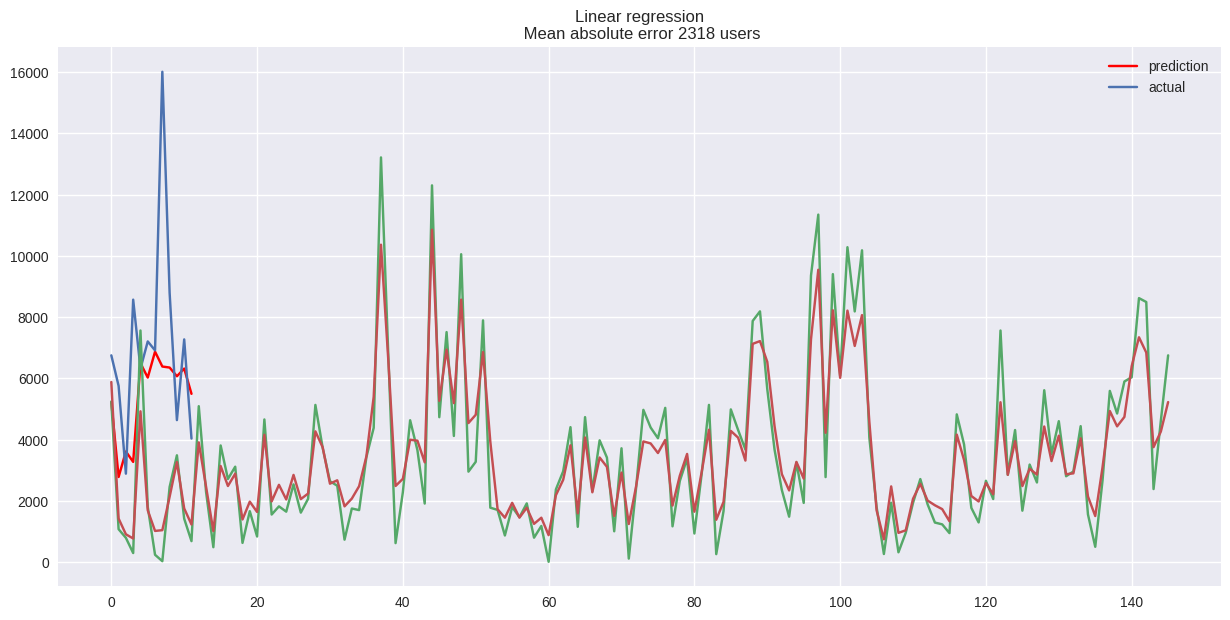

In [114]:
plt.figure(figsize=(15, 7))
plt.plot(prediction, "r", label="prediction")
plt.plot(y_test.values, label="actual")
plt.plot(y_train.values)
plt.plot(prediction_train)
plt.legend(loc="best")
plt.title(
    "Linear regression\n Mean absolute error {} users".format(
        round(mean_absolute_error(prediction, y_test))
    )
)
plt.grid(True)

In [125]:
X = pd.concat((X_train, X_test))
X = X.drop_duplicates()
y = pd.concat((y_train, y_test))
y = y.drop_duplicates()

Text(144, 0.8, 'train')

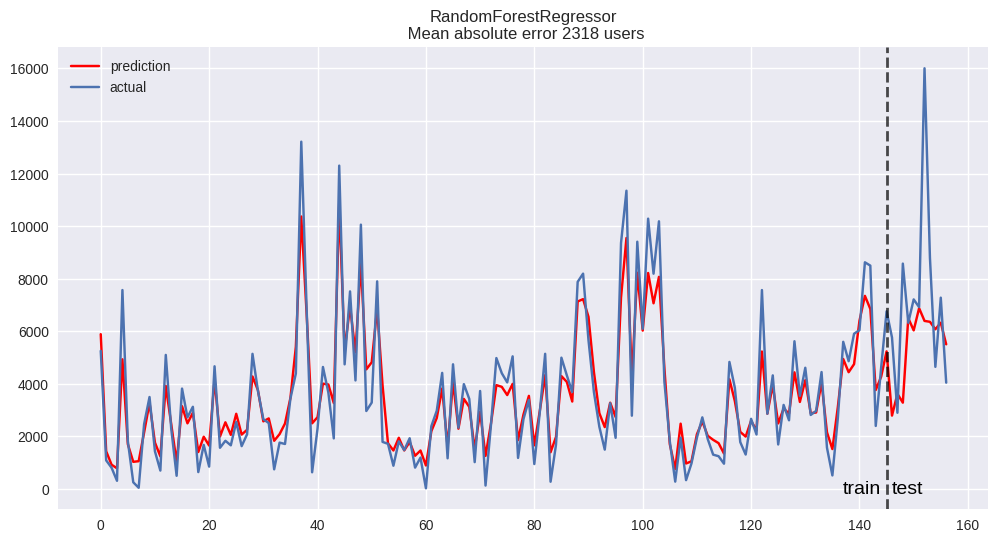

In [138]:
plt.figure(figsize=(12, 6))
plt.plot(rf.predict(X), "r", label="prediction")
plt.plot(y, label="actual")
plt.legend(loc="best")
plt.title(
    "RandomForestRegressor\n Mean absolute error {} users".format(
        round(mean_absolute_error(prediction, y_test))
    )
)
plt.grid(True)
plt.axvline(x=X_train.index[-1], color="black", linestyle="--", linewidth=2, alpha=0.7)

# Добавляем подписи
plt.text(
    X_train.index[-1] + 1,
    0.8,
    "test",
    fontsize=14,
    color="black",
    verticalalignment="center",
    horizontalalignment="left",
)
plt.text(
    X_train.index[-1] - 1,
    0.8,
    "train",
    fontsize=14,
    color="black",
    verticalalignment="center",
    horizontalalignment="right",
)

9. Создайте Streamlit-приложение, в которое пользователь сможет загрузить свой файл с временным рядом, и получить результат предсказания, а так же метрики и интерпретацию результатов

10*. Если останется время, можно попробовать дополнительно одну из библиотек: 
* [Darts](https://habr.com/ru/articles/659405/)
* [Merlion](https://habr.com/ru/companies/sportmaster_lab/articles/792318/)
* [tsfresh](https://tsfresh.readthedocs.io/en/latest/)
* [Kats](https://github.com/facebookresearch/Kats)
* [autots](https://winedarksea.github.io/AutoTS/build/html/source/tutorial.html)

In [ ]:
# code

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сохрани файл для __github__. 
